In [13]:
! pip install -q ultralytics

## Import Dependecies 

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
from PIL import Image, ImageOps
import os
from pathlib import Path

import shutil

from sklearn.model_selection import train_test_split
import yaml

In [15]:
# Load CSV
df = pd.read_csv('/kaggle/input/datasets/martinkoome/shoe-annotation/shoe_annotations.csv')
unique_images = df['filename'].unique()
selected_images = random.sample(list(unique_images), 12)

In [16]:
df

,filename,image_width,image_height,class,xmin,ymin,width,height
0,shoe_110.jpeg,1200,1599,shoe,397,225,311,817
1,shoe_100.jpeg,1200,1599,shoe,110,561,950,395
2,shoe_102.jpeg,1200,1599,shoe,358,238,411,951
3,shoe_106.jpeg,1200,1599,shoe,358,129,387,846
4,shoe_104.jpeg,1200,1599,shoe,357,382,514,949
...,...,...,...,...,...,...,...,...
157,shoe_32.jpeg,1280,574,shoe,232,89,738,360
158,shoe_56.jpeg,1280,574,shoe,238,52,806,423
159,shoe_78.jpg,6936,9248,shoe,1280,3020,4564,2769
160,shoe_86.jpg,6936,9248,shoe,3014,3904,929,1004


## Visualize a sample 

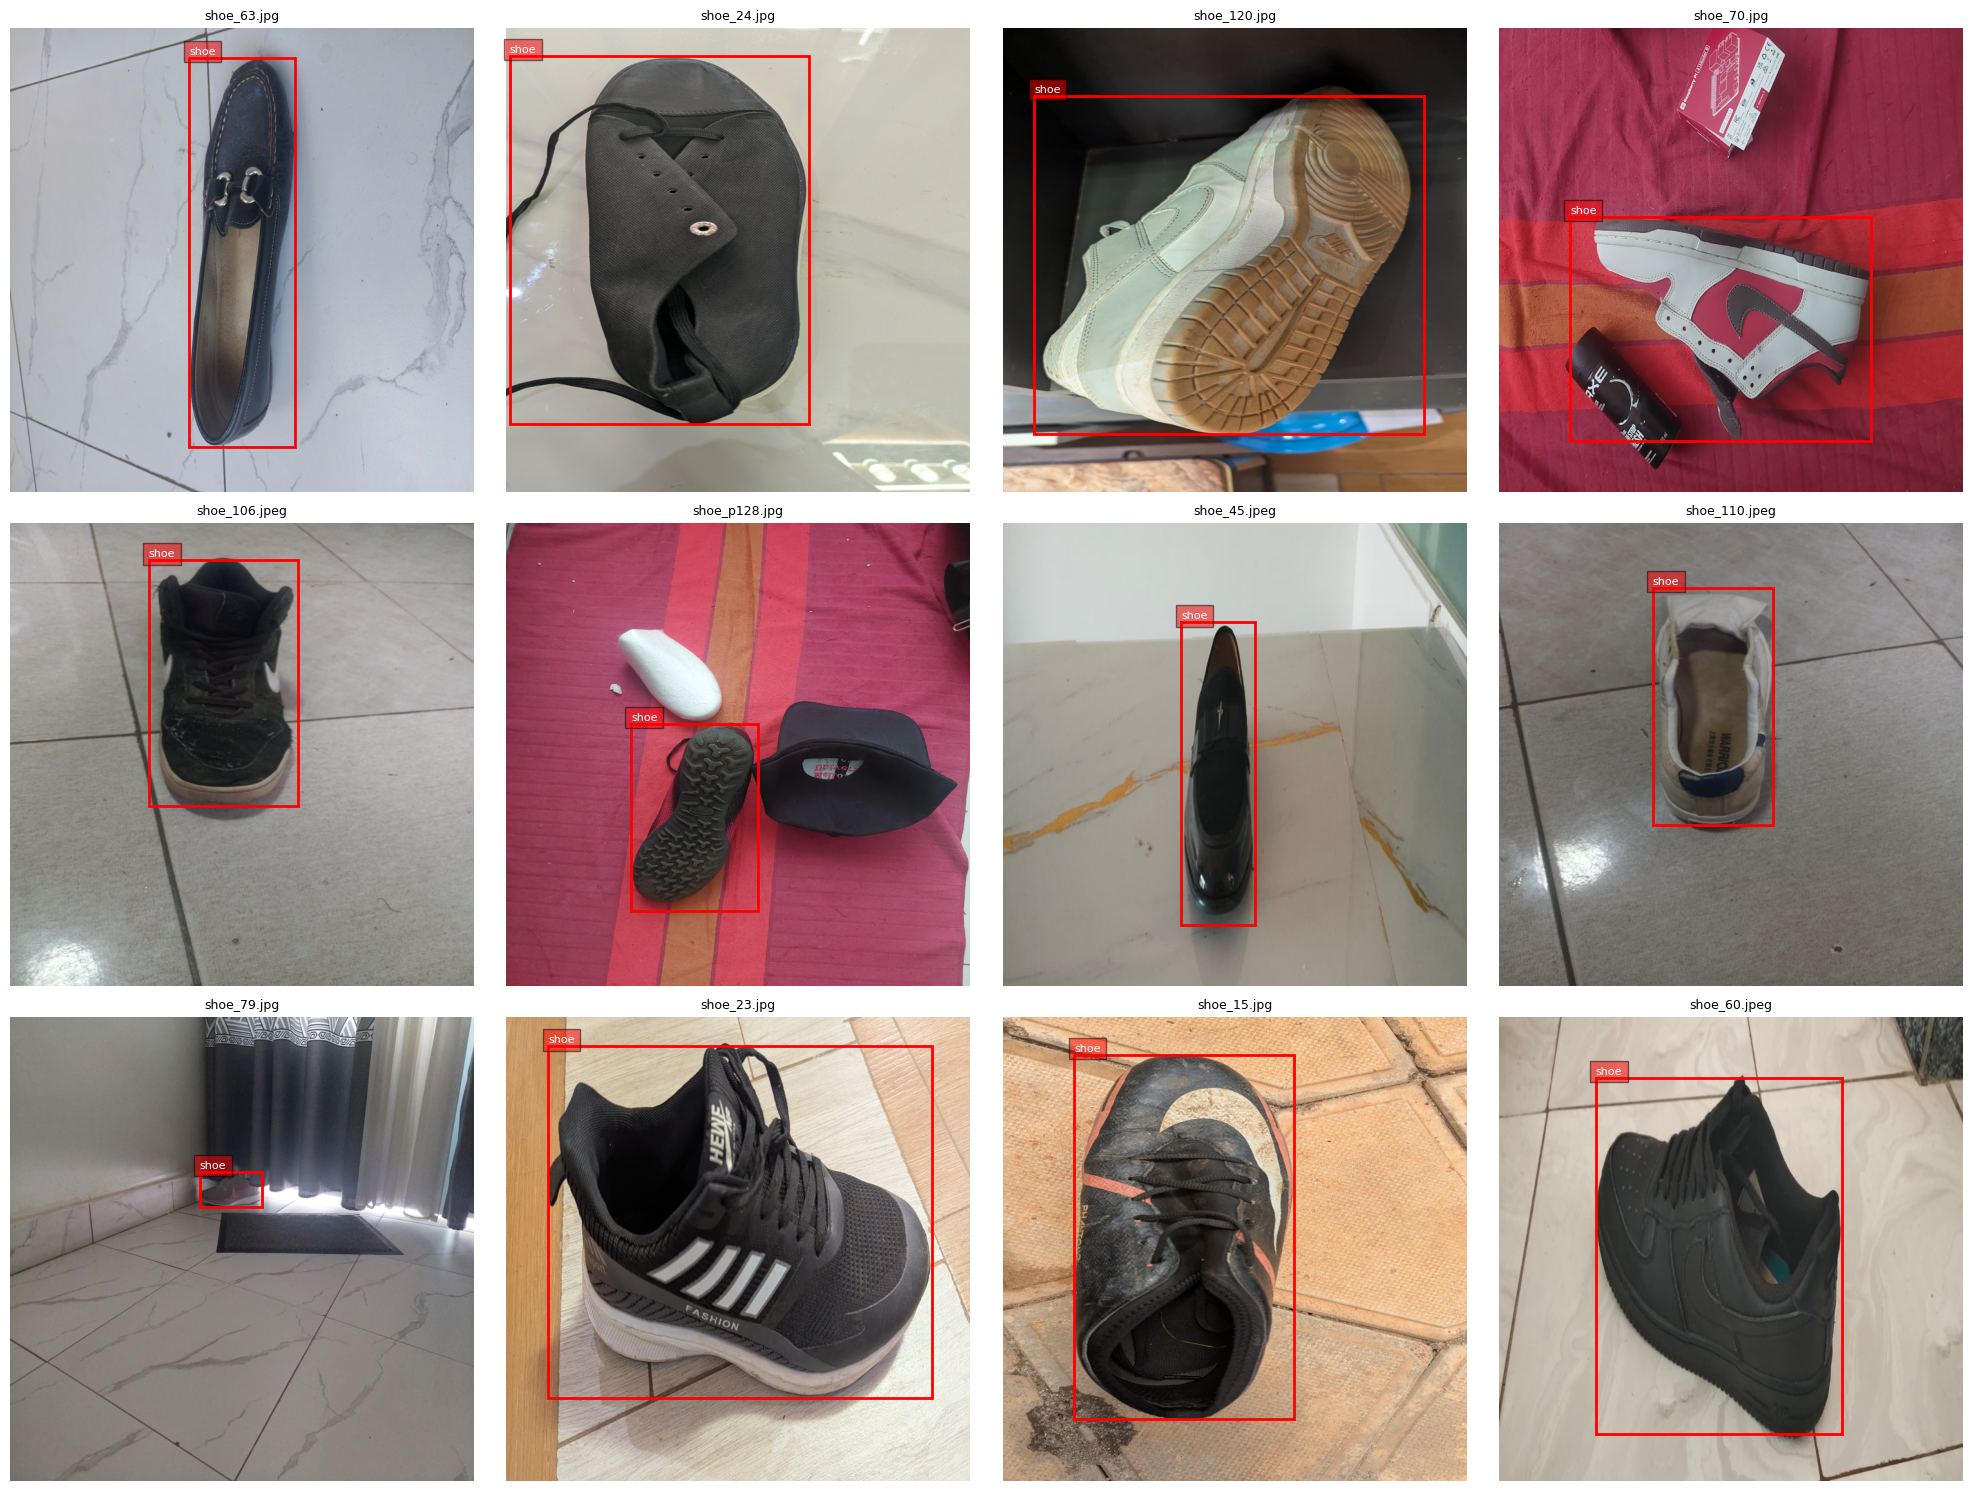

In [17]:
# Setup plot
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()
TARGET_SIZE = 720

for i, filename in enumerate(selected_images):
    img_path = Path('/kaggle/input/datasets/mitchmatheri/acv-hw4-shoe-dataset/data/raw') / filename
    
    if img_path.exists():
        # Open and immediately fix EXIF rotation
        img = Image.open(img_path)
        img = ImageOps.exif_transpose(img) 
        
        orig_w, orig_h = img.size
        
        # Resize and scale
        img_resized = img.resize((TARGET_SIZE, TARGET_SIZE))
        axes[i].imshow(img_resized)
        
        scale_x = TARGET_SIZE / orig_w
        scale_y = TARGET_SIZE / orig_h
    else:
        axes[i].text(0.5, 0.5, "File Not Found", ha='center', va='center', color='red')
        scale_x, scale_y = 1, 1

    # Filter and plot annotations
    image_anns = df[df['filename'] == filename]
    for _, row in image_anns.iterrows():
        new_xmin = row['xmin'] * scale_x
        new_ymin = row['ymin'] * scale_y
        new_w = row['width'] * scale_x
        new_h = row['height'] * scale_y

        rect = patches.Rectangle((new_xmin, new_ymin), new_w, new_h, 
                                 linewidth=2, edgecolor='r', facecolor='none')
        axes[i].add_patch(rect)
        axes[i].text(new_xmin, new_ymin - 5, row['class'], 
                     color='white', fontsize=8, bbox=dict(facecolor='red', alpha=0.5))

    axes[i].set_title(filename, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Data Preparation 

In [18]:

YOLO_IMG_SIZE = 640  # Standard YOLO training size

class YOLODatasetPreparator:
    def __init__(self, csv_path, images_dir, output_dir, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
        self.csv_path = csv_path
        self.images_dir = Path(images_dir)
        self.output_dir = Path(output_dir)
        self.train_ratio = train_ratio
        self.val_ratio = val_ratio
        self.test_ratio = test_ratio
        
        assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6

    # --------------------------------------------------
    # LOAD ANNOTATIONS
    # --------------------------------------------------
    def load_annotations(self):
        print("Loading annotations...")
        self.df = pd.read_csv(self.csv_path)

        self.classes = sorted(self.df['class'].unique().tolist())
        self.class_to_id = {cls: idx for idx, cls in enumerate(self.classes)}

        print("Classes:", self.class_to_id)

    # --------------------------------------------------
    # CREATE FOLDERS
    # --------------------------------------------------
    def create_directory_structure(self):
        for split in ['train','val','test']:
            (self.output_dir / split / 'images').mkdir(parents=True, exist_ok=True)
            (self.output_dir / split / 'labels').mkdir(parents=True, exist_ok=True)

    # --------------------------------------------------
    # SPLIT DATASET
    # --------------------------------------------------
    def split_dataset(self):
        unique_images = self.df['filename'].unique()

        train_val, test = train_test_split(unique_images, test_size=self.test_ratio, random_state=42)
        val_ratio_adjusted = self.val_ratio / (self.train_ratio + self.val_ratio)
        train, val = train_test_split(train_val, test_size=val_ratio_adjusted, random_state=42)

        self.splits = {
            'train': train.tolist(),
            'val': val.tolist(),
            'test': test.tolist()
        }

    # --------------------------------------------------
    # CONVERT TO YOLO FORMAT (FIXED)
    # --------------------------------------------------
    def convert_to_yolo_format(self, row, img_w, img_h, scale_x, scale_y):
        class_id = self.class_to_id[row['class']]

        xmin = row['xmin'] * scale_x
        ymin = row['ymin'] * scale_y
        width = row['width'] * scale_x
        height = row['height'] * scale_y

        x_center = (xmin + width/2) / img_w
        y_center = (ymin + height/2) / img_h
        norm_w = width / img_w
        norm_h = height / img_h

        return f"{class_id} {x_center:.6f} {y_center:.6f} {norm_w:.6f} {norm_h:.6f}"

    # --------------------------------------------------
    # PROCESS IMAGES + LABELS (FULLY FIXED)
    # --------------------------------------------------
    def process_images_and_labels(self):
        print("Processing images and labels...")

        for split_name, image_list in self.splits.items():
            print(f"Processing {split_name}...")

            for filename in image_list:
                img_path = self.images_dir / filename
                if not img_path.exists():
                    continue

                # 1️⃣ Open + FIX EXIF ROTATION (CRITICAL)
                img = Image.open(img_path)
                img = ImageOps.exif_transpose(img)

                # 2️⃣ Get original size
                orig_w, orig_h = img.size

                # 3️⃣ Resize image to YOLO size
                img = img.resize((YOLO_IMG_SIZE, YOLO_IMG_SIZE))

                # 4️⃣ Compute scaling factors for boxes
                scale_x = YOLO_IMG_SIZE / orig_w
                scale_y = YOLO_IMG_SIZE / orig_h

                # 5️⃣ SAVE ROTATED + RESIZED IMAGE (CRITICAL FIX)
                dest_img_path = self.output_dir / split_name / 'images' / filename
                img.save(dest_img_path, quality=95)

                # 6️⃣ Create YOLO label file
                label_filename = Path(filename).stem + ".txt"
                label_path = self.output_dir / split_name / 'labels' / label_filename

                image_annotations = self.df[self.df['filename'] == filename]

                with open(label_path, "w") as f:
                    for _, row in image_annotations.iterrows():
                        yolo_line = self.convert_to_yolo_format(
                            row,
                            YOLO_IMG_SIZE,
                            YOLO_IMG_SIZE,
                            scale_x,
                            scale_y
                        )
                        f.write(yolo_line + "\n")

    # --------------------------------------------------
    # CREATE YAML
    # --------------------------------------------------
    def create_dataset_yaml(self):
        yaml_content = {
            'path': str(self.output_dir.absolute()),
            'train': 'train/images',
            'val': 'val/images',
            'test': 'test/images',
            'nc': len(self.classes),
            'names': self.classes
        }

        with open(self.output_dir / "dataset.yaml", "w") as f:
            yaml.dump(yaml_content, f, sort_keys=False)

    # --------------------------------------------------
    def run(self):
        print("Preparing YOLO dataset (FIXED VERSION)")
        self.load_annotations()
        self.create_directory_structure()
        self.split_dataset()
        self.process_images_and_labels()
        self.create_dataset_yaml()
        print("Dataset ready!")

# ------------------------------------------------------
# RUN
# ------------------------------------------------------
if __name__ == "__main__":
    CSV_PATH = "/kaggle/input/datasets/martinkoome/shoe-annotation/shoe_annotations.csv"
    IMAGES_DIR = "/kaggle/input/datasets/mitchmatheri/acv-hw4-shoe-dataset/data/raw"
    OUTPUT_DIR = "data/yolo_dataset"

    preparator = YOLODatasetPreparator(CSV_PATH, IMAGES_DIR, OUTPUT_DIR)
    preparator.run()

Preparing YOLO dataset (FIXED VERSION)
Loading annotations...
Classes: {'shoe': 0}
Processing images and labels...
Processing train...
Processing val...
Processing test...
Dataset ready!


## Training 

In [19]:
"""
YOLO11 Shoe Detection Pipeline - Step 2: Model Training
Trains YOLO11 model on custom shoe dataset with hyperparameter tuning
"""

import os
from pathlib import Path
from ultralytics import YOLO
import torch
import yaml
from datetime import datetime

class YOLO11Trainer:
    def __init__(self, dataset_yaml, model_size='n', device=None):
        """
        Initialize YOLO11 trainer
        
        Args:
            dataset_yaml: Path to dataset.yaml configuration file
            model_size: YOLO11 model size ('n', 's', 'm', 'l', 'x')
                       n=nano (fastest), s=small, m=medium, l=large, x=xlarge (most accurate)
            device: Training device ('cuda', 'cpu', or None for auto-detection)
        """
        self.dataset_yaml = Path(dataset_yaml)
        self.model_size = model_size
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Load dataset config to get number of classes
        with open(self.dataset_yaml, 'r') as f:
            self.dataset_config = yaml.safe_load(f)
        
        self.num_classes = self.dataset_config['nc']
        self.class_names = self.dataset_config['names']
        
        print(f"Device: {self.device}")
        print(f"Dataset: {self.dataset_yaml}")
        print(f"Classes: {self.class_names}")
        print(f"Number of classes: {self.num_classes}")
        
    def load_pretrained_model(self):
        """Download and load pretrained YOLO11 weights"""
        print("\n" + "="*60)
        print("LOADING PRETRAINED YOLO11 MODEL")
        print("="*60)
        
        model_name = f'yolo11{self.model_size}.pt'
        print(f"Model: {model_name}")
        
        # YOLO will automatically download pretrained weights if not present
        self.model = YOLO(model_name)
        
        print(f"✓ Loaded pretrained {model_name}")
        print(f"  Parameters: {sum(p.numel() for p in self.model.model.parameters()):,}")
        
    def configure_hyperparameters(self, **kwargs):
        """
        Configure training hyperparameters
        
        Default hyperparameters are optimized for shoe detection
        Override with kwargs for experimentation
        """
        # Default hyperparameters (optimized for small-medium datasets)
        self.hyperparameters = {
            'epochs': 20,              # Number of training epochs
            'batch': 16,                # Batch size (adjust based on GPU memory)
            'imgsz': 640,              # Input image size
            'optimizer': 'AdamW',       # Optimizer (AdamW, SGD, Adam)
            'lr0': 0.001,              # Initial learning rate
            'lrf': 0.01,               # Final learning rate (lr0 * lrf)
            'momentum': 0.937,         # SGD momentum/Adam beta1
            'weight_decay': 0.0005,    # Optimizer weight decay
            'warmup_epochs': 3.0,      # Warmup epochs
            'warmup_momentum': 0.8,    # Warmup initial momentum
            'warmup_bias_lr': 0.1,     # Warmup initial bias lr
            'box': 7.5,                # Box loss gain
            'cls': 0.5,                # Class loss gain
            'dfl': 1.5,                # DFL loss gain
            'patience': 50,            # Early stopping patience
            'save': True,              # Save checkpoints
            'save_period': 10,         # Save checkpoint every x epochs
            'cache': False,            # Cache images (True/False/'ram'/'disk')
            'device': self.device,     # Training device
            'workers': 8,              # Number of dataloader workers
            'project': 'runs/train',   # Project directory
            'name': f'yolo11{self.model_size}_shoe_detection',  # Run name
            'exist_ok': True,          # Overwrite existing project/name
            'pretrained': True,        # Use pretrained weights
            'verbose': True,           # Verbose output
            
            # Data Augmentation Parameters
            'hsv_h': 0.015,           # Image HSV-Hue augmentation (fraction)
            'hsv_s': 0.7,             # Image HSV-Saturation augmentation (fraction)
            'hsv_v': 0.4,             # Image HSV-Value augmentation (fraction)
            'degrees': 10.0,          # Image rotation (+/- deg)
            'translate': 0.1,         # Image translation (+/- fraction)
            'scale': 0.5,             # Image scale (+/- gain)
            'shear': 0.0,             # Image shear (+/- deg)
            'perspective': 0.0,       # Image perspective (+/- fraction)
            'flipud': 0.0,            # Image flip up-down (probability)
            'fliplr': 0.5,            # Image flip left-right (probability)
            'mosaic': 1.0,            # Mosaic augmentation (probability)
            'mixup': 0.0,             # Image mixup (probability)
            'copy_paste': 0.0,        # Copy-paste augmentation (probability)
        }
        
        # Override with custom parameters
        self.hyperparameters.update(kwargs)
        
        print("\n" + "="*60)
        print("TRAINING HYPERPARAMETERS")
        print("="*60)
        for key, value in self.hyperparameters.items():
            print(f"  {key:20s}: {value}")
        
    def train(self):
        """Execute model training"""
        print("\n" + "="*60)
        print("STARTING TRAINING")
        print("="*60)
        print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        
        # Train the model
        results = self.model.train(
            data=str(self.dataset_yaml),
            **self.hyperparameters
        )
        
        print("\n" + "="*60)
        print("TRAINING COMPLETE!")
        print("="*60)
        
        return results
    
    def save_config(self):
        """Save training configuration for reproducibility"""
        config = {
            'dataset': str(self.dataset_yaml),
            'model_size': self.model_size,
            'num_classes': self.num_classes,
            'class_names': self.class_names,
            'device': str(self.device),
            'hyperparameters': self.hyperparameters,
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        
        config_dir = Path(self.hyperparameters['project']) / self.hyperparameters['name']
        config_dir.mkdir(parents=True, exist_ok=True)
        config_path = config_dir / 'training_config.yaml'
        
        with open(config_path, 'w') as f:
            yaml.dump(config, f, default_flow_style=False, sort_keys=False)
        
        print(f"\nTraining configuration saved to: {config_path}")
    
    def run(self, **hyperparameter_overrides):
        """
        Execute complete training pipeline
        
        Args:
            **hyperparameter_overrides: Custom hyperparameters to override defaults
        """
        print("="*70)
        print("YOLO11 MODEL TRAINING PIPELINE")
        print("="*70)
        
        self.load_pretrained_model()
        self.configure_hyperparameters(**hyperparameter_overrides)
        self.save_config()
        results = self.train()
        
        return results


def train_multiple_configurations():
    """
    Train multiple model configurations for comparison
    Useful for group projects where each member trains different configurations
    """
    
    configurations = [
        {
            'name': 'baseline',
            'model_size': 'n',
            'epochs': 100,
            'batch': 16,
            'lr0': 0.001,
            'imgsz': 640
        },
        {
            'name': 'high_lr',
            'model_size': 'n',
            'epochs': 100,
            'batch': 16,
            'lr0': 0.01,  # 10x higher learning rate
            'imgsz': 640
        },
        {
            'name': 'large_batch',
            'model_size': 'n',
            'epochs': 100,
            'batch': 32,  # Larger batch size
            'lr0': 0.001,
            'imgsz': 640
        },
        {
            'name': 'high_res',
            'model_size': 's',
            'epochs': 100,
            'batch': 8,
            'lr0': 0.001,
            'imgsz': 1280  # Higher resolution
        }
    ]
    
    results_summary = []
    
    for config in configurations:
        print("\n" + "="*70)
        print(f"TRAINING CONFIGURATION: {config['name'].upper()}")
        print("="*70)
        
        name = config.pop('name')
        model_size = config.pop('model_size')
        
        trainer = YOLO11Trainer(
            dataset_yaml='data/yolo_dataset/dataset.yaml',
            model_size=model_size
        )
        
        config['name'] = f'yolo11{model_size}_{name}'
        results = trainer.run(**config)
        
        results_summary.append({
            'configuration': name,
            'model_size': model_size,
            'results': results
        })
    
    return results_summary


if __name__ == "__main__":
    # ============================================================================
    # CONFIGURATION
    # ============================================================================
    
    # Choose one of the following training modes:
    
    # MODE 1: Single model training (recommended for initial training)
    SINGLE_MODEL_MODE = True
    
    # MODE 2: Multiple configurations (for group comparison)
    MULTIPLE_CONFIGS_MODE = False
    
    # ============================================================================
    
    if SINGLE_MODEL_MODE:
        # Train a single model with specified hyperparameters
        trainer = YOLO11Trainer(
            dataset_yaml='data/yolo_dataset/dataset.yaml',
            model_size='n'  # Options: 'n', 's', 'm', 'l', 'x'
        )
        
        # Customize hyperparameters here
        results = trainer.run(
            epochs=50,
            batch=16,
            imgsz=640,
            lr0=0.001,
            patience=50,
            # Add more custom parameters as needed
        )
    
    elif MULTIPLE_CONFIGS_MODE:
        # Train multiple configurations for comparison
        results_summary = train_multiple_configurations()
        
        print("\n" + "="*70)
        print("ALL CONFIGURATIONS TRAINED SUCCESSFULLY")
        print("="*70)
        for result in results_summary:
            print(f"  ✓ {result['configuration']} (YOLO11{result['model_size']})")
    
    print("\n" + "="*70)
    print("NEXT STEP: Run 3_evaluate_model.py to evaluate performance")
    print("="*70)

Device: cuda
Dataset: data/yolo_dataset/dataset.yaml
Classes: ['shoe']
Number of classes: 1
YOLO11 MODEL TRAINING PIPELINE

LOADING PRETRAINED YOLO11 MODEL
Model: yolo11n.pt
✓ Loaded pretrained yolo11n.pt
  Parameters: 2,624,080

TRAINING HYPERPARAMETERS
  epochs              : 50
  batch               : 16
  imgsz               : 640
  optimizer           : AdamW
  lr0                 : 0.001
  lrf                 : 0.01
  momentum            : 0.937
  weight_decay        : 0.0005
  warmup_epochs       : 3.0
  warmup_momentum     : 0.8
  warmup_bias_lr      : 0.1
  box                 : 7.5
  cls                 : 0.5
  dfl                 : 1.5
  patience            : 50
  save                : True
  save_period         : 10
  cache               : False
  device              : cuda
  workers             : 8
  project             : runs/train
  name                : yolo11n_shoe_detection
  exist_ok            : True
  pretrained          : True
  verbose             : True
  hsv_h 

## Evaluation 

Loading model from: /kaggle/working/runs/detect/runs/train/yolo11n_shoe_detection/weights/best.pt
Device: cuda
YOLO11 COMPLETE MODEL EVALUATION

EVALUATING ON VALIDATION SET
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.4.34 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2146.9±570.4 MB/s, size: 98.8 KB)
val: Scanning /kaggle/working/data/yolo_dataset/val/labels.cache... 22 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 22/22 6.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.3it/s 0.9s1.6s
                   all         22         24      0.916      0.907      0.957      0.712
Speed: 5.1ms preprocess, 12.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Saving /kaggle/working/runs/detect/val3/predictions.json..

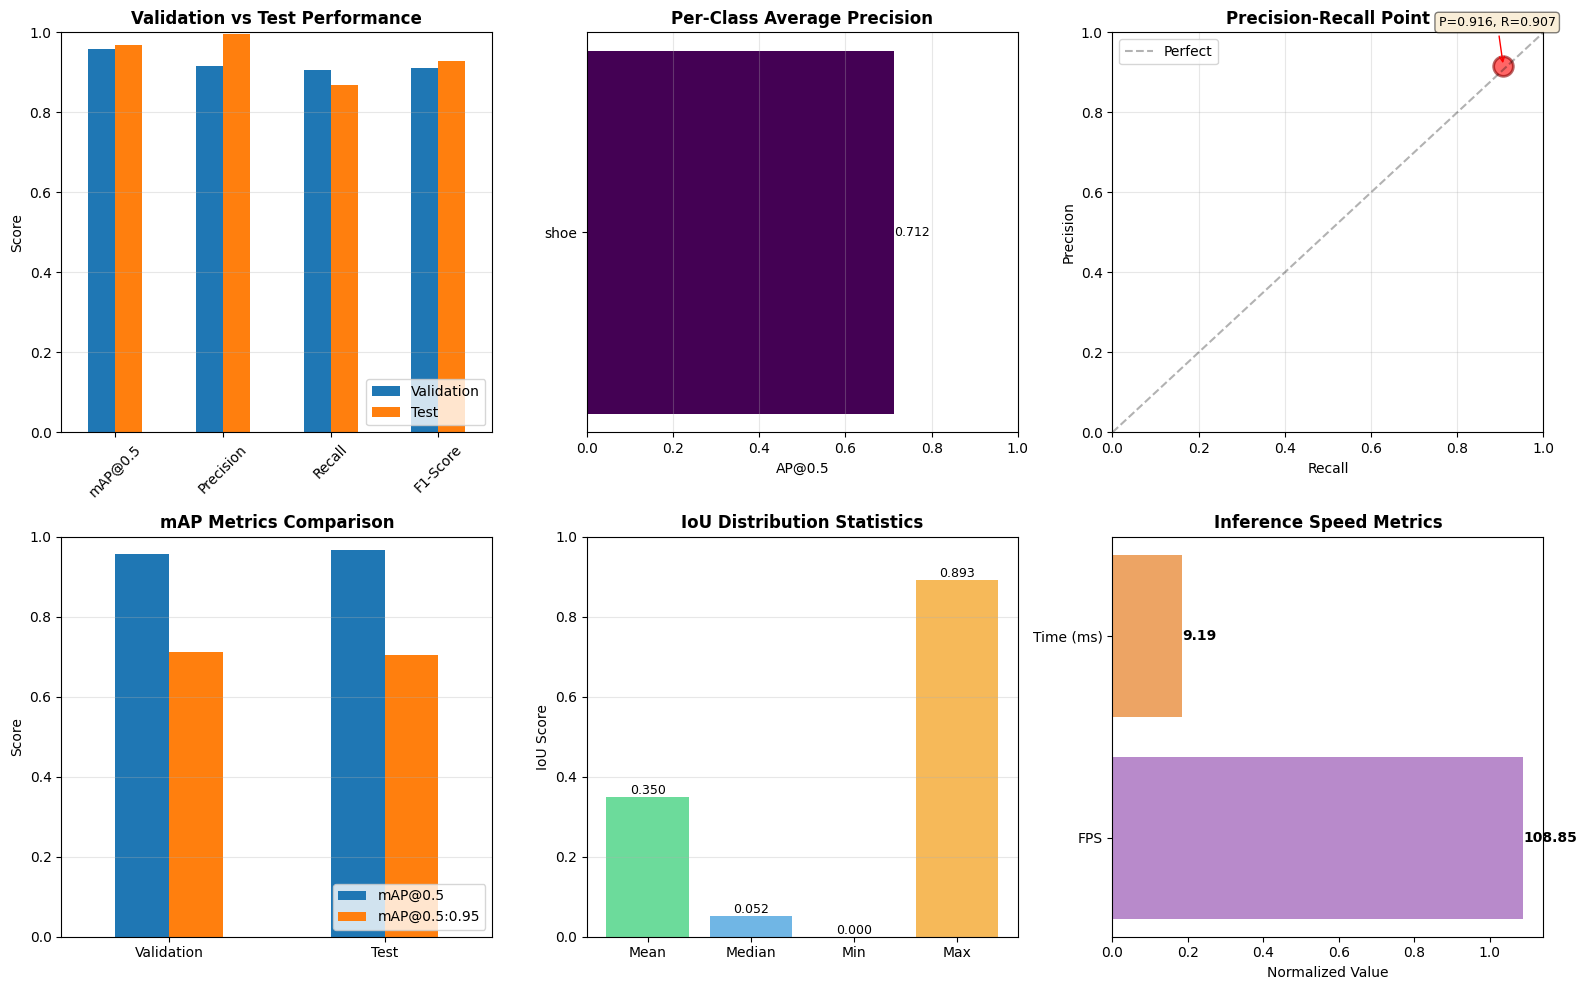


Results saved to: evaluation_results/evaluation_results.json
Report saved to: evaluation_results/evaluation_report.txt

EVALUATION COMPLETE!
Results saved to: /kaggle/working/evaluation_results


In [20]:
"""
YOLO11 Shoe Detection Pipeline - Step 3: Model Evaluation
Comprehensive evaluation with mAP, IoU, Precision, Recall, FPS, and visual analysis
"""

import os
from pathlib import Path
from ultralytics import YOLO
import torch
import yaml
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from PIL import Image
import cv2

class YOLO11Evaluator:
    def __init__(self, model_path, dataset_yaml, output_dir='evaluation_results'):
        """
        Initialize model evaluator
        
        Args:
            model_path: Path to trained model weights (.pt file)
            dataset_yaml: Path to dataset.yaml configuration
            output_dir: Directory to save evaluation results
        """
        self.model_path = Path(model_path)
        self.dataset_yaml = Path(dataset_yaml)
        self.output_dir = Path(output_dir)
        self.output_dir.mkdir(parents=True, exist_ok=True)
        
        # Load model
        print(f"Loading model from: {self.model_path}")
        self.model = YOLO(str(self.model_path))
        
        # Load dataset config
        with open(self.dataset_yaml, 'r') as f:
            self.dataset_config = yaml.safe_load(f)
        
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f"Device: {self.device}")
        
        # Initialize results storage
        self.results = {}
        
    def evaluate_validation_set(self):
        """
        Evaluate model on validation set
        Computes mAP, Precision, Recall, and other metrics
        """
        print("\n" + "="*60)
        print("EVALUATING ON VALIDATION SET")
        print("="*60)
        
        # Run validation
        metrics = self.model.val(
            data=str(self.dataset_yaml),
            split='val',
            save_json=True,
            save_hybrid=True,
            conf=0.25,  # Confidence threshold
            iou=0.5,    # IoU threshold for NMS
            device=self.device
        )
        
        # Extract metrics
        self.results['validation'] = {
            'mAP50': float(metrics.box.map50),      # mAP at IoU=0.50
            'mAP50-95': float(metrics.box.map),     # mAP at IoU=0.50:0.95
            'precision': float(metrics.box.mp),     # Mean precision
            'recall': float(metrics.box.mr),        # Mean recall
            'f1_score': self._calculate_f1(float(metrics.box.mp), float(metrics.box.mr))
        }
        
        # Per-class metrics
        self.results['per_class_metrics'] = {}
        for i, class_name in enumerate(self.dataset_config['names']):
            if i < len(metrics.box.maps):
                self.results['per_class_metrics'][class_name] = {
                    'AP50': float(metrics.box.maps[i]),
                    'precision': float(metrics.box.p[i]) if hasattr(metrics.box, 'p') else None,
                    'recall': float(metrics.box.r[i]) if hasattr(metrics.box, 'r') else None,
                }
        
        print("\nValidation Metrics:")
        print(f"  mAP@0.5      : {self.results['validation']['mAP50']:.4f}")
        print(f"  mAP@0.5:0.95 : {self.results['validation']['mAP50-95']:.4f}")
        print(f"  Precision    : {self.results['validation']['precision']:.4f}")
        print(f"  Recall       : {self.results['validation']['recall']:.4f}")
        print(f"  F1-Score     : {self.results['validation']['f1_score']:.4f}")
        
        return metrics
    
    def evaluate_test_set(self):
        """Evaluate model on test set"""
        print("\n" + "="*60)
        print("EVALUATING ON TEST SET")
        print("="*60)
        
        metrics = self.model.val(
            data=str(self.dataset_yaml),
            split='test',
            save_json=True,
            save_hybrid=True,
            conf=0.25,
            iou=0.5,
            device=self.device
        )
        
        self.results['test'] = {
            'mAP50': float(metrics.box.map50),
            'mAP50-95': float(metrics.box.map),
            'precision': float(metrics.box.mp),
            'recall': float(metrics.box.mr),
            'f1_score': self._calculate_f1(float(metrics.box.mp), float(metrics.box.mr))
        }
        
        print("\nTest Metrics:")
        print(f"  mAP@0.5      : {self.results['test']['mAP50']:.4f}")
        print(f"  mAP@0.5:0.95 : {self.results['test']['mAP50-95']:.4f}")
        print(f"  Precision    : {self.results['test']['precision']:.4f}")
        print(f"  Recall       : {self.results['test']['recall']:.4f}")
        print(f"  F1-Score     : {self.results['test']['f1_score']:.4f}")
        
        return metrics
    
    def measure_inference_speed(self, num_images=100, image_size=640):
        """
        Measure inference speed (FPS)
        
        Args:
            num_images: Number of images to test
            image_size: Image size for inference
        """
        print("\n" + "="*60)
        print("MEASURING INFERENCE SPEED")
        print("="*60)
        
        # Create dummy image
        dummy_image = np.random.randint(0, 255, (image_size, image_size, 3), dtype=np.uint8)
        
        # Warmup
        print("Warming up...")
        for _ in range(10):
            _ = self.model.predict(dummy_image, verbose=False, device=self.device)
        
        # Measure inference time
        print(f"Running inference on {num_images} images...")
        start_time = time.time()
        
        for _ in range(num_images):
            _ = self.model.predict(dummy_image, verbose=False, device=self.device)
        
        total_time = time.time() - start_time
        avg_time = total_time / num_images
        fps = num_images / total_time
        
        self.results['inference_speed'] = {
            'average_time_ms': avg_time * 1000,
            'fps': fps,
            'num_images_tested': num_images,
            'image_size': image_size,
            'device': str(self.device)
        }
        
        print(f"\nInference Speed:")
        print(f"  Average time : {avg_time*1000:.2f} ms/image")
        print(f"  FPS          : {fps:.2f}")
        print(f"  Device       : {self.device}")
        
    def compute_iou_statistics(self, iou_threshold=0.5):
        """
        Compute IoU statistics from predictions
        
        Args:
            iou_threshold: IoU threshold for considering a detection as correct
        """
        print("\n" + "="*60)
        print("COMPUTING IOU STATISTICS")
        print("="*60)
        
        # Get validation images
        val_dir = Path(self.dataset_config['path']) / 'val' / 'images'
        val_images = list(val_dir.glob('*.jpg')) + list(val_dir.glob('*.png'))
        
        if not val_images:
            print("Warning: No validation images found")
            return
        
        # Sample images for IoU computation
        sample_size = min(50, len(val_images))
        sample_images = np.random.choice(val_images, sample_size, replace=False)
        
        iou_scores = []
        
        for img_path in sample_images:
            # Run prediction
            results = self.model.predict(str(img_path), verbose=False, device=self.device)
            
            # Load ground truth labels
            label_path = img_path.parent.parent / 'labels' / (img_path.stem + '.txt')
            
            if not label_path.exists():
                continue
            
            # Parse ground truth
            with open(label_path, 'r') as f:
                gt_boxes = []
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        # Convert from YOLO format (normalized) to pixel coordinates
                        img = Image.open(img_path)
                        w, h = img.size
                        
                        x_center, y_center, width, height = map(float, parts[1:])
                        x1 = (x_center - width/2) * w
                        y1 = (y_center - height/2) * h
                        x2 = (x_center + width/2) * w
                        y2 = (y_center + height/2) * h
                        
                        gt_boxes.append([x1, y1, x2, y2])
            
            # Get predictions
            if len(results) > 0 and results[0].boxes is not None:
                pred_boxes = results[0].boxes.xyxy.cpu().numpy()
                
                # Compute IoU for each prediction
                for pred_box in pred_boxes:
                    for gt_box in gt_boxes:
                        iou = self._compute_iou(pred_box, gt_box)
                        iou_scores.append(iou)
        
        if iou_scores:
            self.results['iou_statistics'] = {
                'mean_iou': float(np.mean(iou_scores)),
                'median_iou': float(np.median(iou_scores)),
                'std_iou': float(np.std(iou_scores)),
                'min_iou': float(np.min(iou_scores)),
                'max_iou': float(np.max(iou_scores)),
                'above_threshold': float(np.mean(np.array(iou_scores) >= iou_threshold))
            }
            
            print(f"\nIoU Statistics (from {len(iou_scores)} detections):")
            print(f"  Mean IoU     : {self.results['iou_statistics']['mean_iou']:.4f}")
            print(f"  Median IoU   : {self.results['iou_statistics']['median_iou']:.4f}")
            print(f"  Std IoU      : {self.results['iou_statistics']['std_iou']:.4f}")
            print(f"  Above {iou_threshold:.2f}   : {self.results['iou_statistics']['above_threshold']*100:.1f}%")
        
    def _compute_iou(self, box1, box2):
        """Compute IoU between two boxes [x1, y1, x2, y2]"""
        x1_inter = max(box1[0], box2[0])
        y1_inter = max(box1[1], box2[1])
        x2_inter = min(box1[2], box2[2])
        y2_inter = min(box1[3], box2[3])
        
        if x2_inter < x1_inter or y2_inter < y1_inter:
            return 0.0
        
        intersection = (x2_inter - x1_inter) * (y2_inter - y1_inter)
        
        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
        union = area1 + area2 - intersection
        
        return intersection / union if union > 0 else 0.0
    
    def _calculate_f1(self, precision, recall):
        """Calculate F1 score from precision and recall"""
        if precision + recall == 0:
            return 0.0
        return 2 * (precision * recall) / (precision + recall)
    
    def visualize_predictions(self, num_samples=9):
        """
        Create visual analysis of predictions
        
        Args:
            num_samples: Number of sample images to visualize
        """
        print("\n" + "="*60)
        print("CREATING VISUAL ANALYSIS")
        print("="*60)
        
        # Get test images
        test_dir = Path(self.dataset_config['path']) / 'test' / 'images'
        test_images = list(test_dir.glob('*.jpg')) + list(test_dir.glob('*.png'))
        
        if not test_images:
            print("Warning: No test images found")
            return
        
        # Sample random images
        sample_images = np.random.choice(test_images, min(num_samples, len(test_images)), replace=False)
        
        # Create grid plot
        rows = int(np.ceil(np.sqrt(num_samples)))
        cols = int(np.ceil(num_samples / rows))
        
        fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
        axes = axes.flatten() if num_samples > 1 else [axes]
        
        for idx, img_path in enumerate(sample_images):
            # Run prediction
            results = self.model.predict(str(img_path), verbose=False, device=self.device)
            
            # Plot annotated image
            annotated_img = results[0].plot()
            
            # Convert BGR to RGB
            annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
            
            axes[idx].imshow(annotated_img)
            axes[idx].set_title(f"{img_path.name}", fontsize=8)
            axes[idx].axis('off')
        
        # Hide extra subplots
        for idx in range(len(sample_images), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        
        # Save visualization
        viz_path = self.output_dir / 'prediction_samples.png'
        plt.savefig(viz_path, dpi=150, bbox_inches='tight')
        print(f"Saved prediction visualization to: {viz_path}")
        plt.close()
    
    def create_performance_charts(self):
        """Create performance visualization charts"""
        print("\n" + "="*60)
        print("CREATING PERFORMANCE CHARTS")
        print("="*60)
        
        # Create figure with subplots
        fig = plt.figure(figsize=(16, 10))
        
        # 1. Validation vs Test Metrics
        ax1 = plt.subplot(2, 3, 1)
        metrics_comparison = pd.DataFrame({
            'Validation': [
                self.results['validation']['mAP50'],
                self.results['validation']['precision'],
                self.results['validation']['recall'],
                self.results['validation']['f1_score']
            ],
            'Test': [
                self.results['test']['mAP50'],
                self.results['test']['precision'],
                self.results['test']['recall'],
                self.results['test']['f1_score']
            ]
        }, index=['mAP@0.5', 'Precision', 'Recall', 'F1-Score'])
        
        metrics_comparison.plot(kind='bar', ax=ax1, rot=45)
        ax1.set_title('Validation vs Test Performance', fontweight='bold')
        ax1.set_ylabel('Score')
        ax1.set_ylim([0, 1])
        ax1.legend(loc='lower right')
        ax1.grid(axis='y', alpha=0.3)
        
        # 2. Per-class AP scores
        ax2 = plt.subplot(2, 3, 2)
        class_names = list(self.results['per_class_metrics'].keys())
        ap_scores = [self.results['per_class_metrics'][c]['AP50'] for c in class_names]
        
        colors = plt.cm.viridis(np.linspace(0, 1, len(class_names)))
        bars = ax2.barh(class_names, ap_scores, color=colors)
        ax2.set_xlabel('AP@0.5')
        ax2.set_title('Per-Class Average Precision', fontweight='bold')
        ax2.set_xlim([0, 1])
        ax2.grid(axis='x', alpha=0.3)
        
        # Add value labels
        for bar, score in zip(bars, ap_scores):
            width = bar.get_width()
            ax2.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{score:.3f}', ha='left', va='center', fontsize=9)
        
        # 3. Precision-Recall Trade-off
        ax3 = plt.subplot(2, 3, 3)
        precision = self.results['validation']['precision']
        recall = self.results['validation']['recall']
        
        ax3.scatter([recall], [precision], s=200, c='red', alpha=0.6, edgecolors='darkred', linewidths=2)
        ax3.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect')
        ax3.set_xlabel('Recall')
        ax3.set_ylabel('Precision')
        ax3.set_title('Precision-Recall Point', fontweight='bold')
        ax3.set_xlim([0, 1])
        ax3.set_ylim([0, 1])
        ax3.grid(alpha=0.3)
        ax3.legend()
        
        # Annotate point
        ax3.annotate(f'P={precision:.3f}, R={recall:.3f}', 
                    xy=(recall, precision), xytext=(recall-0.15, precision+0.1),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # 4. mAP Comparison
        ax4 = plt.subplot(2, 3, 4)
        map_data = pd.DataFrame({
            'mAP@0.5': [self.results['validation']['mAP50'], self.results['test']['mAP50']],
            'mAP@0.5:0.95': [self.results['validation']['mAP50-95'], self.results['test']['mAP50-95']]
        }, index=['Validation', 'Test'])
        
        map_data.plot(kind='bar', ax=ax4, rot=0)
        ax4.set_title('mAP Metrics Comparison', fontweight='bold')
        ax4.set_ylabel('Score')
        ax4.set_ylim([0, 1])
        ax4.legend(loc='lower right')
        ax4.grid(axis='y', alpha=0.3)
        
        # 5. IoU Distribution
        if 'iou_statistics' in self.results:
            ax5 = plt.subplot(2, 3, 5)
            iou_stats = self.results['iou_statistics']
            
            categories = ['Mean', 'Median', 'Min', 'Max']
            values = [iou_stats['mean_iou'], iou_stats['median_iou'], 
                     iou_stats['min_iou'], iou_stats['max_iou']]
            
            colors_iou = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
            bars = ax5.bar(categories, values, color=colors_iou, alpha=0.7)
            ax5.set_ylabel('IoU Score')
            ax5.set_title('IoU Distribution Statistics', fontweight='bold')
            ax5.set_ylim([0, 1])
            ax5.grid(axis='y', alpha=0.3)
            
            # Add value labels
            for bar, val in zip(bars, values):
                height = bar.get_height()
                ax5.text(bar.get_x() + bar.get_width()/2., height,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=9)
        
        # 6. Inference Speed
        ax6 = plt.subplot(2, 3, 6)
        fps = self.results['inference_speed']['fps']
        avg_time = self.results['inference_speed']['average_time_ms']
        
        metrics_speed = ['FPS', 'Time (ms)']
        values_speed = [fps, avg_time]
        colors_speed = ['#9b59b6', '#e67e22']
        
        # Normalize for visualization
        norm_values = [fps / 100, avg_time / 50]  # Adjust scaling as needed
        
        bars = ax6.barh(metrics_speed, norm_values, color=colors_speed, alpha=0.7)
        ax6.set_xlabel('Normalized Value')
        ax6.set_title('Inference Speed Metrics', fontweight='bold')
        
        # Add actual value labels
        for bar, val in zip(bars, values_speed):
            width = bar.get_width()
            ax6.text(width, bar.get_y() + bar.get_height()/2,
                    f'{val:.2f}', ha='left', va='center', fontsize=10, fontweight='bold')
        
        plt.tight_layout()
        
        # Save chart
        chart_path = self.output_dir / 'performance_charts.png'
        plt.savefig(chart_path, dpi=300, bbox_inches='tight')
        print(f"Saved performance charts to: {chart_path}")
        plt.show()
    
    def save_results(self):
        """Save evaluation results to JSON file"""
        results_path = self.output_dir / 'evaluation_results.json'
        
        # Add metadata
        self.results['metadata'] = {
            'model_path': str(self.model_path),
            'dataset': str(self.dataset_yaml),
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'device': str(self.device)
        }
        
        with open(results_path, 'w') as f:
            json.dump(self.results, f, indent=2)
        
        print(f"\nResults saved to: {results_path}")
    
    def generate_report(self):
        """Generate comprehensive evaluation report"""
        report_path = self.output_dir / 'evaluation_report.txt'
        
        with open(report_path, 'w') as f:
            f.write("="*70 + "\n")
            f.write("YOLO11 SHOE DETECTION - MODEL EVALUATION REPORT\n")
            f.write("="*70 + "\n\n")
            
            f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write(f"Model: {self.model_path}\n")
            f.write(f"Dataset: {self.dataset_yaml}\n\n")
            
            f.write("="*70 + "\n")
            f.write("VALIDATION SET METRICS\n")
            f.write("="*70 + "\n")
            for key, value in self.results['validation'].items():
                f.write(f"  {key:20s}: {value:.4f}\n")
            
            f.write("\n" + "="*70 + "\n")
            f.write("TEST SET METRICS\n")
            f.write("="*70 + "\n")
            for key, value in self.results['test'].items():
                f.write(f"  {key:20s}: {value:.4f}\n")
            
            f.write("\n" + "="*70 + "\n")
            f.write("PER-CLASS METRICS\n")
            f.write("="*70 + "\n")
            for class_name, metrics in self.results['per_class_metrics'].items():
                f.write(f"\n{class_name}:\n")
                for metric, value in metrics.items():
                    if value is not None:
                        f.write(f"  {metric:15s}: {value:.4f}\n")
            
            f.write("\n" + "="*70 + "\n")
            f.write("INFERENCE SPEED\n")
            f.write("="*70 + "\n")
            for key, value in self.results['inference_speed'].items():
                f.write(f"  {key:20s}: {value}\n")
            
            if 'iou_statistics' in self.results:
                f.write("\n" + "="*70 + "\n")
                f.write("IOU STATISTICS\n")
                f.write("="*70 + "\n")
                for key, value in self.results['iou_statistics'].items():
                    f.write(f"  {key:20s}: {value:.4f}\n")
        
        print(f"Report saved to: {report_path}")
    
    def run_complete_evaluation(self):
        """Execute complete evaluation pipeline"""
        print("="*70)
        print("YOLO11 COMPLETE MODEL EVALUATION")
        print("="*70)
        
        # Run all evaluation steps
        self.evaluate_validation_set()
        self.evaluate_test_set()
        self.measure_inference_speed()
        self.compute_iou_statistics()
        self.visualize_predictions()
        self.create_performance_charts()
        self.save_results()
        self.generate_report()
        
        print("\n" + "="*70)
        print("EVALUATION COMPLETE!")
        print("="*70)
        print(f"Results saved to: {self.output_dir.absolute()}")


if __name__ == "__main__":
    # Configuration
    MODEL_PATH = "/kaggle/working/runs/detect/runs/train/yolo11n_shoe_detection/weights/best.pt"
    DATASET_YAML = "/kaggle/working/data/yolo_dataset/dataset.yaml"
    OUTPUT_DIR = "evaluation_results"
    
    # Initialize evaluator
    evaluator = YOLO11Evaluator(
        model_path=MODEL_PATH,
        dataset_yaml=DATASET_YAML,
        output_dir=OUTPUT_DIR
    )
    
    # Run complete evaluation
    evaluator.run_complete_evaluation()